[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_4_Relationships.ipynb)

# 07.4: Relationships Between Two Numeric Variables

Every chart so far has had one numeric axis and one categorical axis (or no axes at all, for histograms). Now both axes are numeric. The questions change accordingly: not "how many?" or "what fraction?" but "do these two variables move together, and if so, how?"

This notebook covers scatter plots, regression lines, and line plots. Each answers a slightly different version of the relationship question.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## The scatter plot: raw relationships

The most direct way to ask whether two numeric variables are related is to plot one on the x-axis and one on the y-axis. Each passenger becomes a dot. If the dots slope upward from left to right, the variables are positively associated. If they slope downward, negatively. If they form a shapeless cloud, there is no clear linear relationship.

Let's start with the most obvious question: did passengers who paid more tend to be older?

Text(0, 0.5, 'Fare (pounds)')

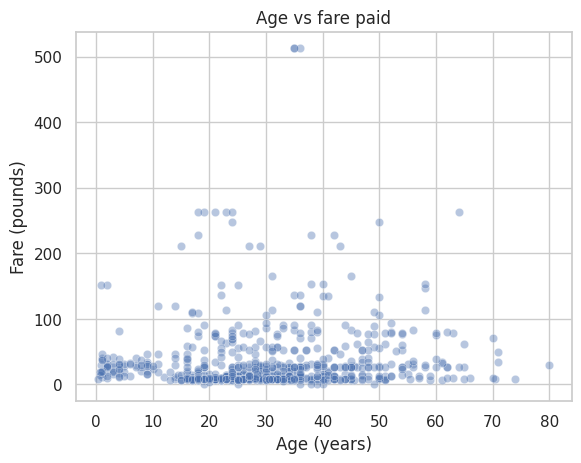

In [2]:
ax = sns.scatterplot(data=df, x="age", y="fare", alpha=0.4)
ax.set_title("Age vs fare paid")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare (pounds)")

The cloud has no obvious slope. Age and fare are not strongly related: a 20-year-old and a 60-year-old were equally likely to appear anywhere in the fare range. The extreme fares (above 200 pounds) appear at various ages, not concentrated in any age group.

The `alpha=0.4` parameter makes each dot slightly transparent. Where many dots overlap, the area looks darker; where few overlap, the dots are pale. This **overplotting** treatment is important whenever many data points share similar values, which is common here (many passengers paid fares below 50 pounds and were in their 20s).

Adding `hue=` colors each dot by a third variable. Let's see whether survivors and non-survivors cluster differently in age-fare space.

Text(0, 0.5, 'Fare (pounds)')

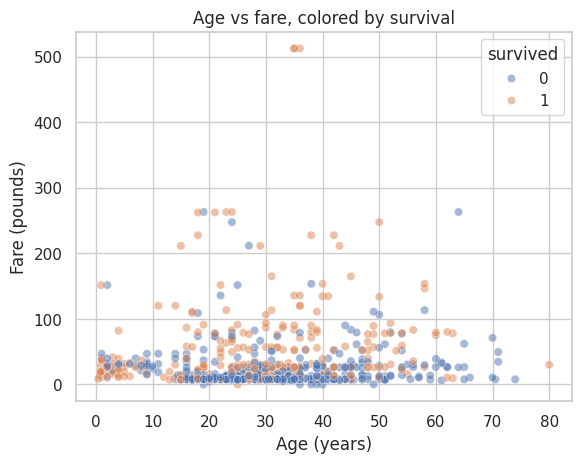

In [3]:
ax = sns.scatterplot(data=df, x="age", y="fare",
                     hue="survived", alpha=0.5)
ax.set_title("Age vs fare, colored by survival")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare (pounds)")

The survivors (orange) are spread throughout the plot, but there is a visible concentration of survivors at higher fares. This reflects the class effect: passengers who paid more were in higher classes and survived more often. Age does not show a clear pattern here by itself.

## Adding a trend line

A scatter plot shows individual points. A regression line summarizes the overall trend with a single straight line, fitted so that it minimizes the total vertical distance from each point to the line. `sns.regplot()` draws both at once.

Text(0, 0.5, 'Fare (pounds)')

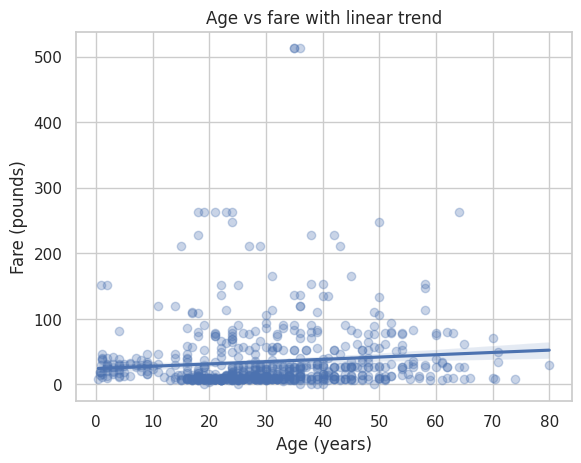

In [4]:
ax = sns.regplot(data=df, x="age", y="fare", scatter_kws={"alpha": 0.3})
ax.set_title("Age vs fare with linear trend")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare (pounds)")

The blue line is the fitted linear regression. The shaded band around it is a 95% confidence interval: not for individual predictions, but for the location of the line itself. A wide band means the data does not strongly constrain where the line should go.

The line has a very slight positive slope (older passengers paid slightly more on average), but the band is very wide and the scatter is enormous. This confirms what the scatter plot suggested: the linear relationship between age and fare is weak.

When the relationship is curved, you can fit a polynomial instead of a straight line with `order=2` (quadratic) or a flexible nonparametric curve with `lowess=True`.

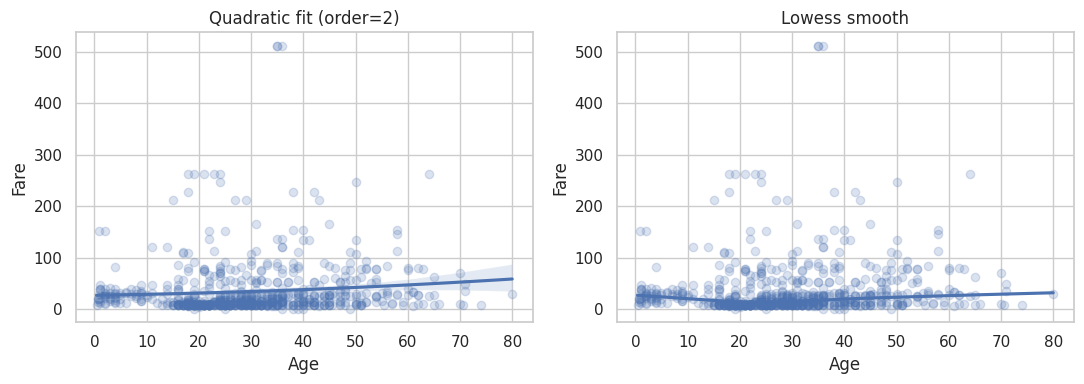

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.regplot(data=df, x="age", y="fare",
            order=2, scatter_kws={"alpha": 0.2}, ax=axes[0])
axes[0].set_title("Quadratic fit (order=2)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Fare")

sns.regplot(data=df, x="age", y="fare",
            lowess=True, scatter_kws={"alpha": 0.2}, ax=axes[1])
axes[1].set_title("Lowess smooth")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Fare")

plt.tight_layout()

Neither fit reveals a strong pattern. The lowess curve (a locally weighted smoother that makes no assumptions about shape) wiggles modestly but stays fairly flat. This is informative: it tells you that no simple functional form relates age to fare in this dataset. The relationship is not linear, quadratic, or any other clean shape.

## Line plots: trends across a numeric axis

A scatter plot shows individual observations. A line plot shows an aggregated trend. `sns.lineplot()` computes the mean of y at each unique value of x and connects the means with a line. It also draws a confidence band showing the uncertainty around each mean.

The Titanic data has no time column, but we can still use a line plot to ask: how does survival rate change as a function of age? For each age value in the data, seaborn will compute the average of `survived` (which equals the survival rate) and draw the trend.

(0.0, 1.0)

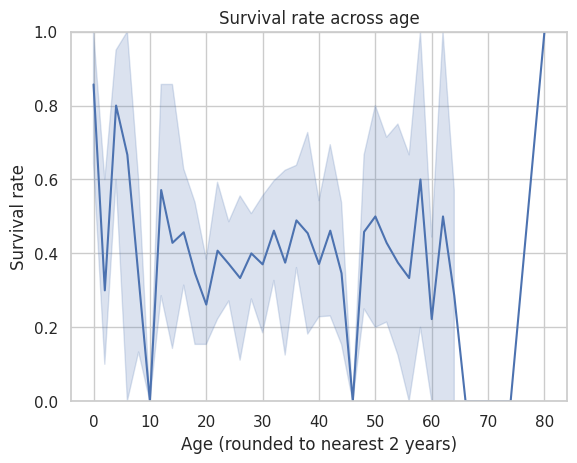

In [6]:
# Round age to nearest 2 years so the line is smoother
df_line = df.dropna(subset=["age"]).copy()
df_line["age_r"] = (df_line["age"] / 2).round() * 2

ax = sns.lineplot(data=df_line, x="age_r", y="survived", errorbar="ci")
ax.set_title("Survival rate across age")
ax.set_xlabel("Age (rounded to nearest 2 years)")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

Children under 10 had notably higher survival rates than adults, consistent with the evacuation protocol. After roughly age 15, survival rate drops and stays lower, hovering between 30 and 40% for most adult ages. The wide confidence band at older ages reflects the small number of elderly passengers in the dataset: there are few people in their 60s and 70s, so the mean survival rate there is uncertain.

The `errorbar="ci"` argument draws the 95% confidence interval. Where the band is narrow, the estimate is reliable (many passengers at that age). Where it is wide, there were few passengers at that age and the estimate is less certain.

## Multi-line plots: comparing trends across groups

Adding `hue=` draws a separate line for each group. This is where line plots really earn their place: comparing how a trend differs across categories.

(0.0, 1.0)

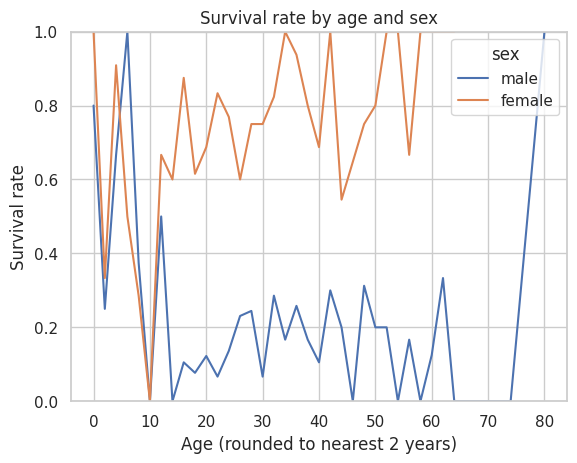

In [7]:
ax = sns.lineplot(
    data=df_line, x="age_r", y="survived",
    hue="sex",
    errorbar=None
)
ax.set_title("Survival rate by age and sex")
ax.set_xlabel("Age (rounded to nearest 2 years)")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

The gender gap is enormous. Female passengers (orange) had survival rates above 70% at almost every age. Male passengers (blue) survived at under 20% across most adult ages. Young boys (under roughly 10) had somewhat higher survival rates than adult men, reflecting the "children first" aspect of the evacuation. But the gap closes and reverses at no point for adults.

Adding `style=` uses a second visual channel (dashed vs solid lines) in addition to color. This is useful for accessibility: readers who cannot distinguish colors can still follow the lines by their dash pattern.

(0.0, 1.0)

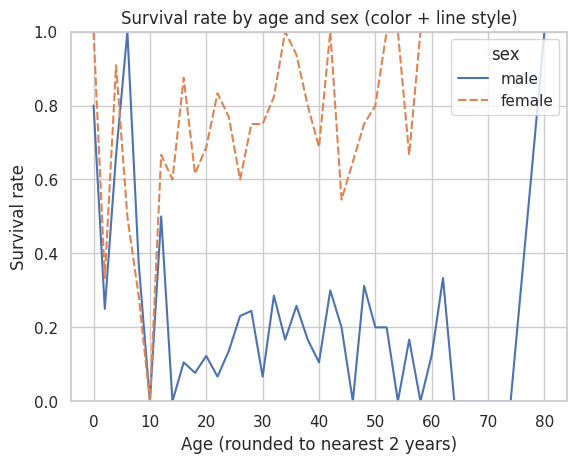

In [8]:
ax = sns.lineplot(
    data=df_line, x="age_r", y="survived",
    hue="sex", style="sex",
    errorbar=None
)
ax.set_title("Survival rate by age and sex (color + line style)")
ax.set_xlabel("Age (rounded to nearest 2 years)")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

## Choosing between scatter, regplot, and lineplot

These three functions overlap in purpose. Here is a quick decision guide:

`sns.scatterplot()` shows raw observations. Use it when you want to see the individual data points, check for outliers, or look for clusters. It does not aggregate anything.

`sns.regplot()` shows raw observations plus a model fit. Use it when you want to know whether a linear (or curved) relationship exists and how strong it is. It draws one line through the data.

`sns.lineplot()` shows aggregated trends. Use it when the individual points are not interesting but the trend of y as a function of x is. It computes the mean of y at each x value and draws that as a line, which is especially powerful with `hue=` to compare trends across groups.

## What's next

You can now chart two numeric variables against each other. But all the charts in this notebook put one thing per panel. In 07.5 you will learn to show three or more variables at once using additional visual channels (color, size, line style) and by splitting the chart into a grid of small panels.